# Decision Tree(의사결정 나무)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report

# 데이터 셋

wine 데이터 셋 rest/white 와인 분류

In [3]:
file_path = "https://bit.ly/wine_csv_data"  # csv 파일이 저장된 GitHub 경로

In [4]:
wine_df = pd.read_csv(file_path)

In [5]:
wine_df.head(n=6)

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0
5,9.4,1.8,3.51,0.0


In [6]:
wine_df.tail(n=6)

,alcohol,sugar,pH,class
6491,9.7,1.3,3.29,1.0
6492,11.2,1.6,3.27,1.0
6493,9.6,8.0,3.15,1.0
6494,9.4,1.2,2.99,1.0
6495,12.8,1.1,3.34,1.0
6496,11.8,0.8,3.26,1.0


In [7]:
# 연속형 자료(숫자 타입) 변수들의 기술 통계량
wine_df.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [8]:
# 카테고리 타입 변수 빈도수(0 - red wine, 1 - white wine)
wine_df["class"].value_counts().sort_index()

,count
class,
0.0,1599
1.0,4898


class 빈도수 막대 그래프

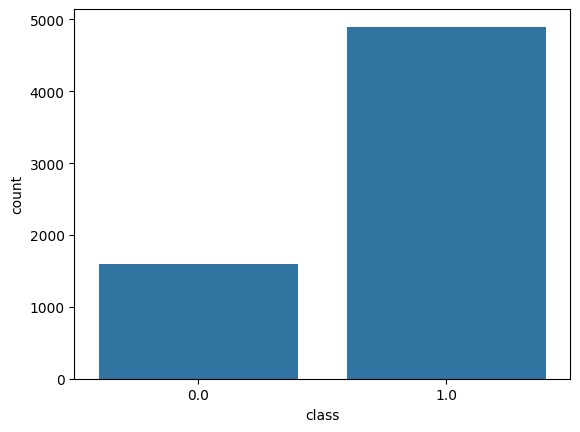

In [13]:
sns.barplot(data=wine_df["class"].value_counts())
plt.show()

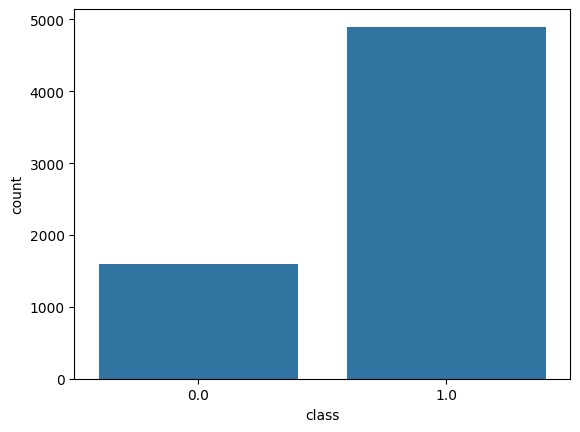

In [19]:
sns.countplot(data=wine_df, x="class")
plt.show()

alcohol, sugar, pH 변수들의 히스토그램

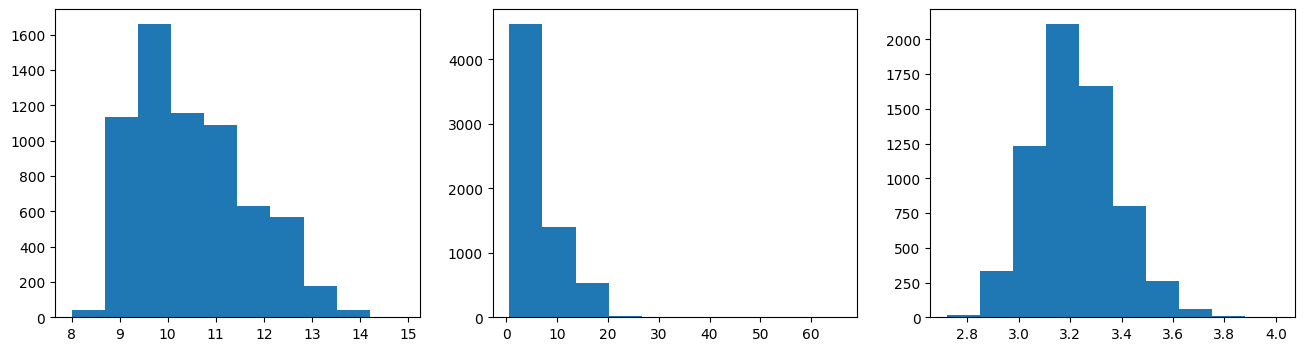

In [25]:
fig, axes = plt.subplots(ncols=3, figsize=(16, 4))

axes[0].hist(wine_df["alcohol"])
axes[1].hist(wine_df["sugar"])
axes[2].hist(wine_df["pH"])

plt.show()

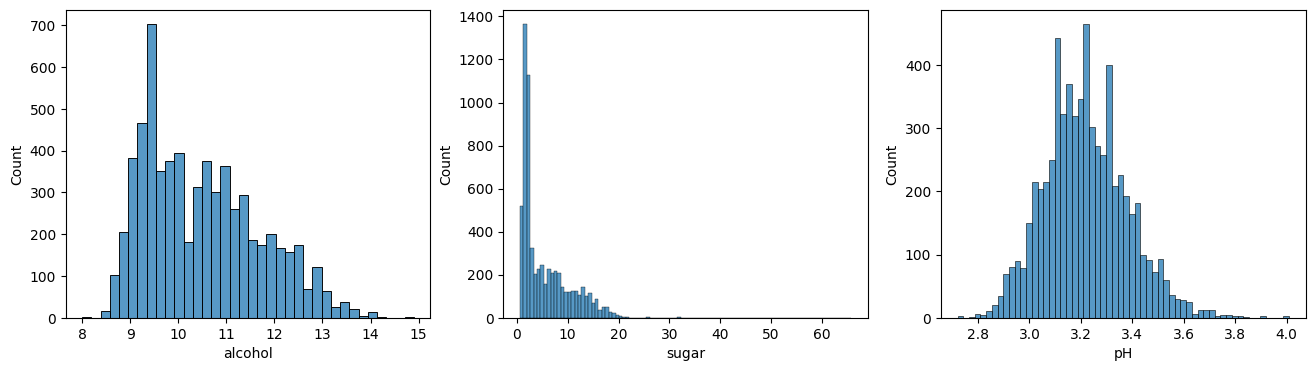

In [27]:
fig, axes = plt.subplots(ncols=3, figsize=(16, 4))

for i, var in enumerate(wine_df.columns[:3]):
    sns.histplot(data=wine_df, x=var, ax=axes[i])


plt.show()

alcohol, sugar, pH 변수들의 pairplot (class별로 색깔을 다르게)

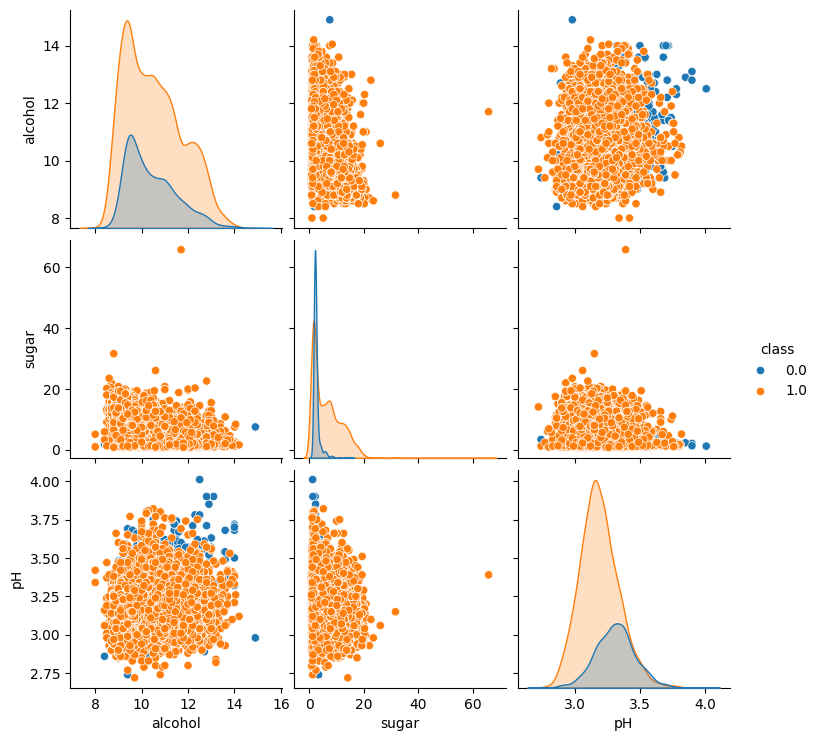

In [32]:
sns.pairplot(data=wine_df, hue="class")
plt.show()

In [36]:
feature_names = wine_df.columns[:3]
target_names = ["red", "white"]
print(feature_names)
print(target_names)

Index(['alcohol', 'sugar', 'pH'], dtype='object')
['red', 'white']


# 훈련 셋, 테스트 셋 나누기

In [38]:
x = wine_df[wine_df.columns[:3]].values  # 특성 배열(2d array)
y = wine_df['class'].values  # 타겟 배열(1d array)

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [44]:
x_train.shape

(5197, 3)

In [46]:
x_test.shape

(1300, 3)

# Decision Tree Classifier

In [47]:
tree_clf = DecisionTreeClassifier(random_state=42)  # 모델 생성

In [48]:
tree_clf.fit(X=x_train, y=y_train)  # 모델 훈련

DecisionTreeClassifier(random_state=42)

In [49]:
train_pred = tree_clf.predict(X=x_train)  # 훈련 셋 예측값
train_pred[:10]

array([1., 1., 1., 0., 0., 0., 1., 1., 1., 0.])

In [50]:
y_train[:10]

array([1., 1., 1., 0., 0., 0., 1., 1., 1., 0.])

In [51]:
cm_train = confusion_matrix(y_true=y_train, y_pred=train_pred)
cm_train

array([[1276,    3],
       [   8, 3910]])

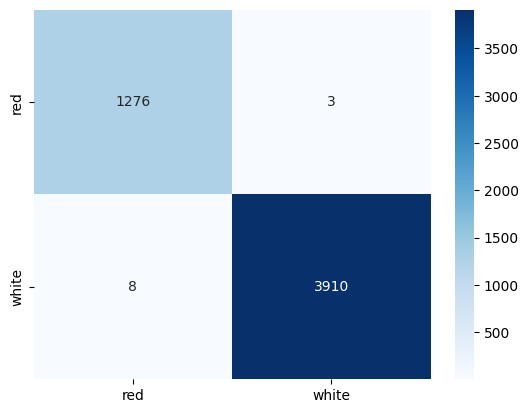

In [53]:
sns.heatmap(data=cm_train, cmap="Blues", annot=True, fmt="d",
            xticklabels=target_names, yticklabels=target_names)

plt.show()

In [56]:
print(classification_report(y_true=y_train, y_pred=train_pred,
                            target_names=target_names))

              precision    recall  f1-score   support

         red       0.99      1.00      1.00      1279
       white       1.00      1.00      1.00      3918

    accuracy                           1.00      5197
   macro avg       1.00      1.00      1.00      5197
weighted avg       1.00      1.00      1.00      5197



In [57]:
test_pred = tree_clf.predict(X=x_test)  # 테스트 셋 예측값
test_pred[:10]

array([0., 1., 1., 1., 1., 1., 0., 1., 1., 1.])

In [58]:
y_test[:10]

array([1., 1., 1., 1., 1., 0., 0., 1., 1., 1.])

In [60]:
cm_test = confusion_matrix(y_true=y_test, y_pred=test_pred)
cm_test

array([[226,  94],
       [ 81, 899]])

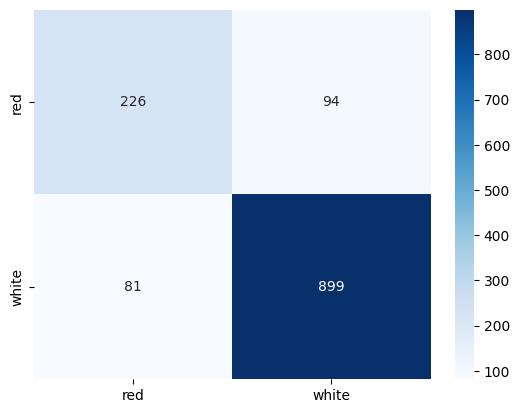

In [63]:
sns.heatmap(data=cm_test, cmap="Blues", annot=True, fmt="d",
            xticklabels=target_names, yticklabels=target_names)

plt.show()

In [64]:
print(classification_report(y_true=y_test, y_pred=test_pred,
                            target_names=target_names))

              precision    recall  f1-score   support

         red       0.74      0.71      0.72       320
       white       0.91      0.92      0.91       980

    accuracy                           0.87      1300
   macro avg       0.82      0.81      0.82      1300
weighted avg       0.86      0.87      0.86      1300



Decision Tree 분류 알고리즘은 과대적합(over-fitting)이 너무 크다!

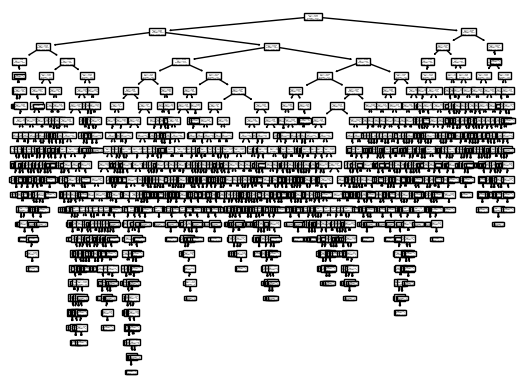

In [66]:
plot_tree(tree_clf)
plt.show()

In [70]:
1 - ((1279/5197)**2 + (3918/5197)**2)

0.37107315616915937

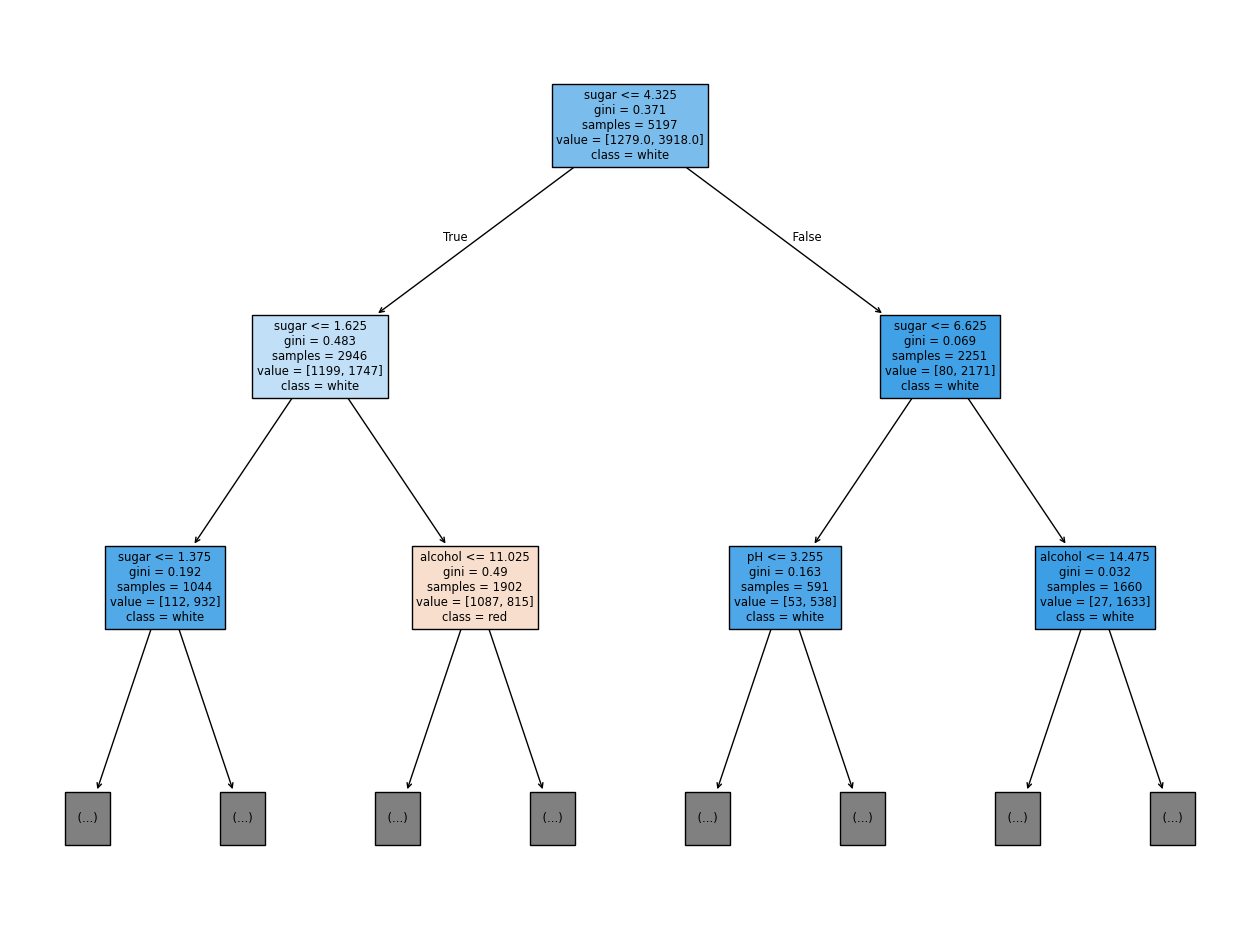

In [69]:
plt.figure(figsize=(16, 12))
plot_tree(tree_clf, max_depth=2, feature_names=feature_names, class_names=target_names, filled=True)
plt.show()

**Decision Tree를 나누는 기준**

---

**Gini impurity(Gini 불순도)**

$$
Gini = 1 - \sum_i p_i^2
$$

*   $ p_i $: i번째 클래스가 될 확률
*   이진(binary-class) 분류
    *   $ Gini = 1 - (p_0^2 + p_1^2) $
    *   양성(positive) 또는 음성(negative)으로 완벽하게 분류가 된 경우, $ Gini = 1 - 1 = 0 $.
        *   Gini 불순도 최소.
    *   양성과 음성이 똑같은 비율로 섞여 있는 경우, $ Gini = 1 - (0.5^2 + 0.5^2) = 0.5 $.
        *   Gini 불순도 최대.
    *   양성과 음성의 비율이 6:4인 경우, $ Gini = 1 - (0.6^2 + 0.4^2) = 0.48 $
*   Decision tree는 부모 노드와 자식 노드의 gini 불순도 차이가 가능한 커지도록 가지를 성장시킴.

---

**Entropy(엔트로피)**

$$
Entropy = -\sum_i p_i \log_k (p_i)
$$

*   $k$: 클래스의 개수(이진 분류인 경우, k=2).
*   $p_i$: $i$번째 클래스가 될 확률.
*   이진 분류
    *   양성과 음성의 비율이 1:1인 경우, Entropy = 1. 엔트로피 최대.
    *   양성 또는 음성으로 완벽히 분류된 경우, Entropy = 0. 엔트로피 최소.
*   Decision tree 객체를 생성할 때 criterion='entropy'라고 설정하면, 부모 노드와 자식 노드에서의 엔트로피 차이가 가능하면 커지도록 가지를 생성함.

---

**Decision Tree 특징**

*   장점:
    *   특성들을 스케일링할 필요가 없다.
    *   결과를 이해하기 쉽다.
*   단점:
    *   과적합(overfitting)되기가 쉽다.
    *   여러가지 규제들을 적용해서 과적합 문제를 해결해야 함.
*   규제 하이퍼 파라미터(hyperparameter) - 생성자의 파라미터들
    *   `max_depth`: decision tree의 최대 깊이.
    *   `max_leaf_node`: leaf node의 최댓값.
    *   `max_features`: 각 노드에서 분할에 사용할 특성의 최대 개수.
    *   `min_samples_split`: 노드가 분할되기 위해서 가져야 할 최소 샘플 개수.
    *   `min_samples_leaf`: leaf 노드가 가져야 할 최소 샘플 개수.
    *   `max_`로 시작하는 파라미터의 값을 증가시키면, 트리의 크기가 커짐.
        *   규제가 작아짐.
        *   overfitting이 커짐.
    *   `max_`로 시작하는 파라미터 값을 감소시키면, 트리의 크기가 작아지기 때문에 overfitting이 작아짐.
    *   `min_`으로 시작하는 파라미터 값을 증가시키면, 트리의 크기가 작아짐.
    

# 하이퍼 파라미터 튜닝

max_depth의 값을 2 ~ 15까지 바꿔가면서 훈련 셋과 테스트 셋에서의 정확도를 계산하고, 시각화.

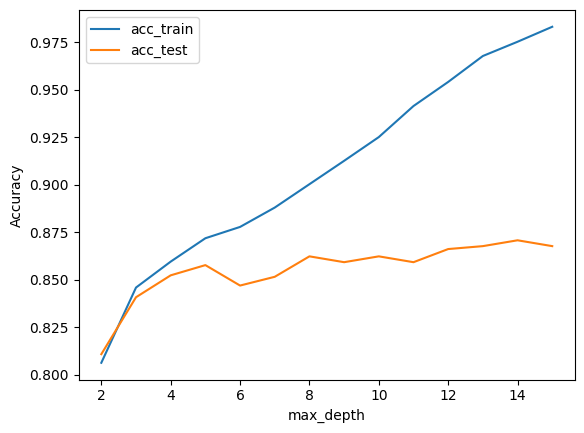

In [76]:
tuning = np.arange(2, 16)
acc_train = []
acc_test = []

for i in tuning:
    tree_clf = DecisionTreeClassifier(max_depth=i)
    tree_clf.fit(X=x_train, y=y_train)
    acc_tr = tree_clf.score(X=x_train, y=y_train)
    acc_train.append(acc_tr)
    acc_te = tree_clf.score(X=x_test, y=y_test)
    acc_test.append(acc_te)

sns.lineplot(x=tuning, y=acc_train, label="acc_train")
sns.lineplot(x=tuning, y=acc_test, label="acc_test")


plt.ylabel("Accuracy")
plt.xlabel("max_depth")
plt.legend()
plt.show()